# Анализ сайта по аренде автомобилей

### Цель: Оптимизация маркетинговых каналов и выявление наиболее эффективных сегментов трафика для площадки по аренде автомобилей.

### Краткие выводы:
1. С мобильного устройства поступает 83,3% трафика.
2. До 43% трафика идет из Москвы.
3. Три самых популярных автомобиля: skoda (частота = 88,5); toyota (частота = 6,2); volkswagen (частота = 3,1).
4. Три автомобиля с лучшими коэффициентами конверсии: skoda (CR = 2,1); toyota (CR = 1,0); volkswagen (CR = 0,0).
5. Доля трафика из соцсетей в выборке, которая идет в целевое действие, составляет 8,3%.

### Загружаем необходимые библиотеки, загружаем данные

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
path_data_sessions = 'data\ga_sessions.csv'
path_data_hits = 'data\ga_hits.csv'

In [3]:
df_data_sessions = pd.read_csv(path_data_sessions)

df_data_hits = pd.read_csv(path_data_hits)

C:\Users\User\AppData\Local\Temp\ipykernel_6488\3645014164.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_sessions = pd.read_csv(path_data_sessions)


### Прописываем необходимые функции

In [4]:
#Удаление удабликатов (при их наличии)
def del_duplicate(df):
    for item in df.duplicated():
        if item == True:
            df.drop_duplicates()
        break
    
    return df    

In [5]:
#Удаляем ненужные/лишние колонки 
def del_columns(df, colums_to_drop):
    df.drop(colums_to_drop, axis = 1, inplace = True)

    return df

In [6]:
# Заполняем пропуски
def full_null_categorial(df):
    #Проверяем наличие пропусков
    if df.isnull().sum().sort_values(ascending = False)[0] != 0:
        
        # Сохраним в переменную categorical имена всех категориальных признаков нашего датасета
        categorical_columns = df.select_dtypes(include = ['object']).columns
        
        # В категориальных фичах заменяем пропуски модой
        for feat in categorical_columns:
            df[feat].fillna(df[feat].mode()[0], inplace = True)

    return df

In [7]:
#Вычленяем модель и марку автомобиля
def separate_brand_model_auto(df):
    df_dop = pd.DataFrame()
    
    #формируем фрейм списков, где первый элемент - модель авто, второй - марка, третий - остаток от ссылки (все заполняется при наличии)
    df_dop['hit_page_path'] = df['hit_page_path'].apply(lambda x: x[x.find('all') + len('all') + 1:].split('/') if x.find('all') != -1 \
                                                        else (x[x.find('car') + len('car') + 1:].split('/') if x.find('car') != -1 \
                                                             else (print(x[x.find('cars') + len('cars') + 1:].split('/')) if x.find('cars') != -1\
                                                                  else [])))
    
    auto = []
    model = []
    kod = []
    
#     разделяем все по отдельным спискам
    for item in df_dop['hit_page_path']:
        if len(item) == 3:
            auto.append(item[0])
            model.append(item[1])
            kod.append(item[2][:item[2].find('?')])
        elif len(item) == 2:
            if len(item[1][:item[1].find('?')]) != 8:
                auto.append(item[1][:item[1].find('?')])
                model.append('')
                kod.append('')
            else:
                auto.append('')
                model.append('')
                kod.append(item[1][:item[1].find('?')])
        elif len(item) == 1:
            auto.append('')
            model.append('')
            kod.append(item[0][:item[0].find('?')])
        else:
            auto.append('')
            model.append('')
            kod.append('')
            
    return auto, model, kod

In [8]:
#Заполняем пропуски названий авто и модeли по номеру иначе с помощью функции full_null_categorial(df)
def full_brand_model_auto(df):
    auto, model, kod = separate_brand_model_auto(df)
    
    #Создаем словарь код авто = (марка, модель)
    kod_auto = {}

    for i in range(0, len(kod)):
        if kod[i] != '' and auto[i] != '':
            kod_auto[kod[i]] = (auto[i], model[i])
            
#     Заполняем пропуски по словарю
    for i in range(0, len(kod)):
        if kod[i] != '' and auto[i] == '' and kod[i] in kod_auto.keys():
            auto[i] = kod_auto[kod[i]][0]
            model[i] = kod_auto[kod[i]][1]
        elif auto[i] == '':
            auto[i] = pd.NA
            model[i] = pd.NA
    
    return auto, model, kod

### Формируем необходимые массивы

In [9]:
#Колонки для удаления
colums_to_drop_sessions = [
    'client_id', 
    'visit_time',
    'visit_number',
    'utm_adcontent',
    'utm_keyword', 
    'device_os',
    'device_brand',
    'device_model',
    'device_screen_resolution',
    'device_browser'
       ]

colums_to_drop_hits = [
    'hit_time',
    'hit_number',
    'hit_type',
    'hit_referer',
    'event_category',
    'event_label',
    'event_value'
       ]

In [10]:
#Массив целевых действий
goal_action = [
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
]

In [11]:
#Реклама в соц сетях
social_ad = [
    'QxAxdyPLuQMEcrdZWdWb',
    'MvfHsxITijuriZxsqZqt',
    'ISrKoXQCxqqYvAZICvjs',
    'IZEXUFLARCUMynmHNBGo',
    'PlbkrSYoHuZBWfYjYnfw',
    'gVRrcxiDQubJiljoTbGm'
]

### Преобразуем датафреймы и объединям в один

In [12]:
####СОБИРАЕМ ВСЕ ВМЕСТЕ
df_data_sessions = del_duplicate(df_data_sessions)
df_data_sessions = del_columns(df_data_sessions, colums_to_drop_sessions)
df_data_sessions = full_null_categorial(df_data_sessions)

df_data_hits = del_duplicate(df_data_hits)
df_data_hits = del_columns(df_data_hits, colums_to_drop_hits)

auto, model, kod = full_brand_model_auto(df_data_hits)
df_data_hits['auto'] = auto
df_data_hits['model'] = model

df_data_hits = del_columns(df_data_hits, 'hit_page_path')
df_data_hits = full_null_categorial(df_data_hits)

C:\Users\User\AppData\Local\Temp\ipykernel_6488\3723976068.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df.isnull().sum().sort_values(ascending = False)[0] != 0:
C:\Users\User\AppData\Local\Temp\ipykernel_6488\3723976068.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feat].fillna(df[feat].mode()[0], inplace = True)
C:\Users

In [13]:
#Объединяем 2 таблицы
df = pd.merge(df_data_sessions, df_data_hits, left_on = 'session_id', right_on = 'session_id')

### Проверка гипотез

In [15]:
#получаем датафрейм, где посчитаны действия необходимые для проверки гипотезы
def create_cr_columns(df, new_col_1, new_col_2, old_col_1, trafic_goal):
    df1 = pd.DataFrame()
    df1['conversion'] = df['conversion'] 
    df1['visit_date'] = df['visit_date']
    df1['session_id'] = df['session_id']
    df1[new_col_1] = df[old_col_1].apply(lambda x: 1 if x in trafic_goal else 0)
    df1[new_col_2] = df[old_col_1].apply(lambda x: 1 if x not in trafic_goal else 0)
    
    df1 = df1.groupby(['visit_date', 'session_id']).max()
    
    return df1.groupby(['visit_date', 'conversion']).sum()

In [16]:
#Проверка нормальности
def test_norm(col_1, alfa):
    p = stats.shapiro(col_1)[1]
    
    if p <= alfa:
        res = 'Данные не распределены нормально.'
    else:
        res = 'Данные распределены нормально.'
    
    return res

In [17]:
#Проверка на равенство дисперсии
def test_desp(col_1, col_2, alfa):
    p = stats.levene(col_1, col_2)[1]
    
    if p <= alfa:
        res = 'Дисперсии не равны.'
    else:
        res = 'Дисперсии равны.'
    
    return res

In [18]:
# Проверка гипотезы с помощью выбранного теста
def check_test(test_name, col_1, col_2, alfa, alternative ='less'):
    test_id = {'Т-Критерий Стьюдента': stats.ttest_ind,
              'Критерий Манна Уитни': stats.mannwhitneyu,
              'Знаковый ранговый тест Вилкоксона': stats.wilcoxon,
              'Парный Т-критерий': stats.ttest_rel}
    
    if test_name == 'Т-Критерий Стьюдента':
        p = test_id[test_name](col_1, col_2)[1]
    else:
        p = test_id[test_name](col_1, col_2, alternative = alternative)[1]
        
    if p <= alfa:
        res = 'Гипотеза Н0 отвергаем, принимаем гипотезу Н1.'
    else:
        res = 'Гипотезу Н0 отклонить нельзя.'
    
    return res

In [19]:
df['conversion'] = df['event_action'].apply(lambda x: 1 if x in goal_action else 0)

In [20]:
# Визуализация по заданному параметру
#list_plot= [color, edgecolor, xlabel, ylabel, title]
def plot_data_all(column_df, name_col_1, name_col_2, list_data, list_plot):
    #Формируем данные для визуализации
    df_plot = pd.DataFrame()
    df_plot['goal'] = column_df.apply(lambda x: name_col_1 if x in list_data else name_col_2)
    
    #Визуализация
    plt.figure(figsize = (8, 5))
    plt.hist(df_plot.goal, color = list_plot[0], edgecolor = list_plot[1])
    plt.xlabel(list_plot[2])
    plt.ylabel(list_plot[3])
    plt.title(list_plot[4])

In [21]:
# Визуализация по заданному параметру в зависимости попадает в целевое действие или нет
#list_plot= [color, edgecolor, xlabel, ylabel, title]
def plot_data_to_goal(column_df, column2_df, name_col_1, name_col_2, list_data, list_plot):
    #Формируем данные для визуализации
    df_plot = pd.DataFrame()
    helper = []
    
    for item, goal in zip(column_df, column2_df):
        if (item in list_data) and (goal == 1):
            helper.append(f'{name_col_1}_to_goal')
        elif (item in list_data) and (goal == 0):
            helper.append(f'{name_col_1}_no_to_goal')
        elif (item not in list_data) and (goal == 1):
            helper.append(f'{name_col_2}_to_goal')
        else:
            helper.append(f'{name_col_2}_no_to_goal')

    df_plot['cr_goal'] = helper

    main_goal = [f'{name_col_1}_to_goal', f'{name_col_2}_to_goal']
    df1 = df_plot[df_plot['cr_goal'].isin(main_goal)]
    
    #Визуализация
    plt.figure(figsize = (8, 5))
    plt.hist(df1.cr_goal, color = list_plot[0], edgecolor = list_plot[1])
    plt.xlabel(list_plot[2])
    plt.ylabel(list_plot[3])
    plt.title(list_plot[4])

In [22]:
#Массив проверки гипотез
hypothesis = []
criterion = []
conclusion = []

### Исходная гипотеза 1:
Органический трафик не отличается от платного с точки зрения CR в целевые события.

In [23]:
#Органический трафик
organic_tr = ['organic', 'referal', 'none']

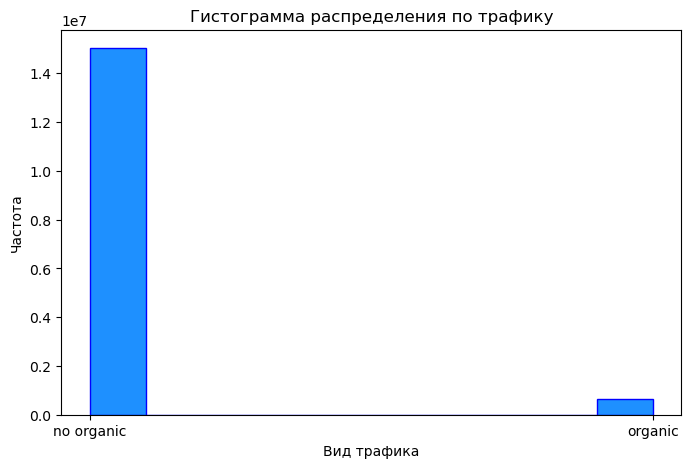

In [24]:
# Визуализируем данные
list_plot= ['dodgerblue', 'blue', 'Вид трафика', 'Частота', 'Гистограмма распределения по трафику']
plot_data_all(df.utm_medium, 'organic', 'no organic', organic_tr, list_plot)

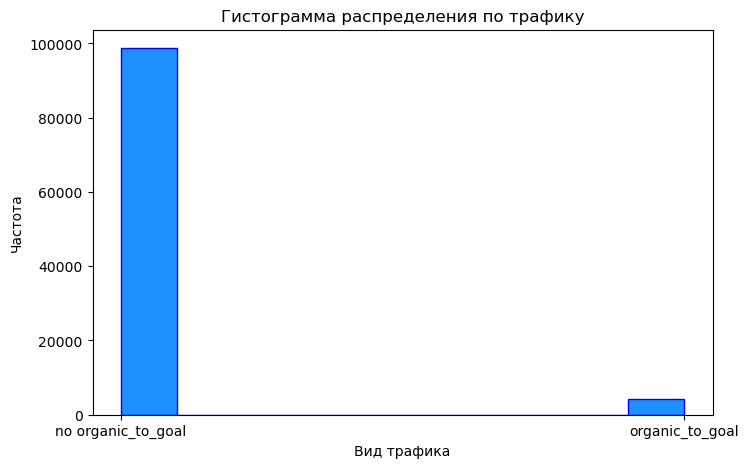

In [25]:
# Визуализируем данные по попаданию в цель
plot_data_to_goal(df.utm_medium, df.conversion, 'organic', 'no organic', organic_tr, list_plot)

In [26]:
df_tr = pd.DataFrame()
df_tr = create_cr_columns(df, 'organ', 'paid', 'utm_medium', organic_tr)

In [27]:
# Cчитаем CR
df_tr['organ_cr'] = df_tr['organ'] / (df_tr.groupby('visit_date').sum().organ + df_tr.groupby('visit_date').sum().paid) * 100
df_tr['paid_cr'] = df_tr['paid'] / (df_tr.groupby('visit_date').sum().organ + df_tr.groupby('visit_date').sum().paid) * 100

###### Гипотезы
Н0: CR органического трафика равно CR платного трафика.

Н1: CR органического трафика отличается от CR платного трафика.

In [28]:
hypothesis.append('Н0: CR органического трафика равно CR платного трафика. \
Н1: CR органического трафика отличается от CR платного трафика.')

In [29]:
# Проверяем на нормальность и равенство дисперсии
print(test_norm(df_tr.organ_cr, 0.05))
print(test_norm(df_tr.paid_cr, 0.05))
print(test_desp(df_tr.organ_cr, df_tr.paid_cr, 0.05))

Данные не распределены нормально.
Данные не распределены нормально.
Дисперсии не равны.


###### Т.к. данные не подчиняются нормальному распределению и независимы, то применяем критерий Манна-Уитни.

In [30]:
criterion.append('Т.к. данные не подчиняются нормальному распределению и независимы, то применяем критерий Манна-Уитни.')

In [31]:
check_test('Критерий Манна Уитни', df_tr.organ_cr, df_tr.paid_cr, 0.05, alternative ='less')

'Гипотеза Н0 отвергаем, принимаем гипотезу Н1.'

###### Вывод.
Согласно критерию Манна-Уитни принимаем гипотезу Н1. Значит, можно сказать, что органический трафик отличается от платного.

In [32]:
conclusion.append('Согласно критерию Манна-Уитни принимаем гипотезу Н1. Значит, можно сказать, что органический трафик отличается от платного.')

### Исходная гипотеза 2:
Трафик с мобильных устройств не отличается от трафика 
с десктопных устройств с точки зрения C 
в целевые события.

In [33]:
#Мобильный трафик
mobile_tr = ['mobile']

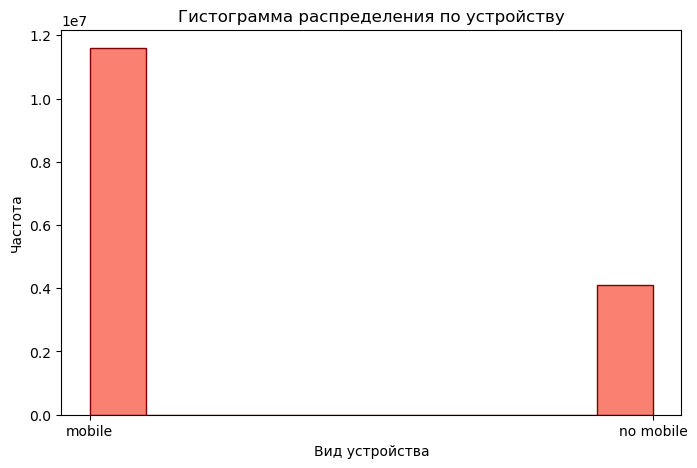

In [34]:
# Визуализируем данные
list_plot= ['salmon', 'maroon', 'Вид устройства', 'Частота', 'Гистограмма распределения по устройству']
plot_data_all(df.device_category, 'mobile', 'no mobile', mobile_tr, list_plot)

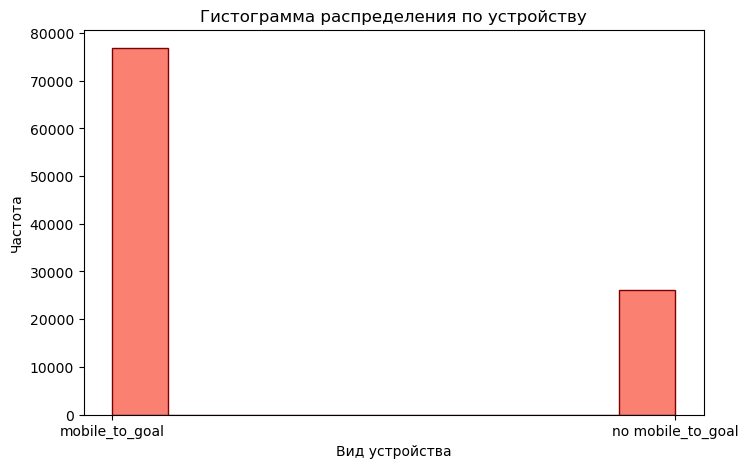

In [35]:
# Визуализируем данные по попаданию в цель
plot_data_to_goal(df.device_category, df.conversion, 'mobile', 'no mobile', mobile_tr, list_plot)

In [36]:
df_dev = pd.DataFrame()
df_dev = create_cr_columns(df, 'mobile', 'desktop', 'device_category', mobile_tr)

In [37]:
# Cчитаем CR
df_dev['mobile_cr'] = df_dev['mobile'] / (df_dev.groupby('visit_date').sum().mobile + df_dev.groupby('visit_date').sum().desktop) * 100
df_dev['desktop_cr'] = df_dev['desktop'] / (df_dev.groupby('visit_date').sum().mobile + df_dev.groupby('visit_date').sum().desktop) * 100

###### Гипотезы
Н0: CR из мобильных устройств равно CR из десктоповых.

Н1: CR из мобильных устройств отличается от CR из десктоповых.

In [38]:
hypothesis.append('Н0: CR из мобильных устройств равно CR из десктоповых. Н1: CR из мобильных устройств отличается от CR из десктоповых.')

In [39]:
# Проверяем на нормальность и равенство дисперсии
print(test_norm(df_dev.mobile_cr, 0.05))
print(test_norm(df_dev.desktop_cr, 0.05))
print(test_desp(df_dev.mobile_cr, df_dev.desktop_cr, 0.05))

Данные не распределены нормально.
Данные не распределены нормально.
Дисперсии не равны.


###### Т.к. данные не подчиняются нормальному распределению и независимы, то применяем критерий Манна-Уитни.

In [40]:
criterion.append('Т.к. данные не подчиняются нормальному распределению и независимы, то применяем критерий Манна-Уитни.')

In [41]:
check_test('Критерий Манна Уитни', df_dev.mobile_cr, df_dev.desktop_cr, 0.05, alternative ='less')

'Гипотезу Н0 отклонить нельзя.'

###### Вывод.¶
Согласно критерию Манна-Уитни принимаем гипотезу Н0. Значит, можно сказать, что трафик из мобильных устройств не отличается от трафика с десктоповых.

In [42]:
conclusion.append('Согласно критерию Манна-Уитни принимаем гипотезу Н0. Значит, можно сказать, что трафик из мобильных устройств не отличается от трафика с десктоповых.')

### Исходная гипотеза 3:
Трафик из городов присутствия (Москва и область, Санкт-Петербург) не отличается от трафика из иных регионов с точки зрения CR в целевые события.

In [43]:
#Трафик из Москвы и области, Санкт_Петербурга
city_tr = ['Saint Petersburg', 'Avsyunino', 'Andreyevka', 'Aprelevka', 'Arkhangelskoye', 'Ateptsevo', 'Ashukino', 'Balashikha', 'Barvikha', \
           'Beloozerskiy', 'Biokombinat', 'Bolshoye Bunkovo', 'Bronnitsy', 'Bykovo', 'Vereya', 'Verbilki', 'Vidnoye', 'Vinogradovo', 'Vlasikha', \
           'VNIISSOK', 'Vnukovo', 'Volokolamsk', 'Vorovskogo', 'Voskresensk', 'Vysokovsk', 'Gzhel', 'Glebovskiy', 'Golitsyno', 'Gorki', 'Davydovo', \
           'Dedenevo', 'Dedovsk', 'Demikhovo', 'Dzerzhinskiy', 'Dmitrov', 'Dolgoprudnyy', 'Domodedovo', 'Dorokhovo', 'Drezna', 'Dubna', 'Yegoryevsk', \
           'Zhavoronki', 'Zheleznodorozhnyy', 'Zhilevo', 'Zhukovskiy', 'Zagoryanskiy', 'Zaprudnya', 'Zaraysk', 'Zvezdnyy gorodok', 'Zvenigorod', \
           'Zelenograd', 'Ivanteyevka', 'Iksha', 'Ilinskiy', 'Istra', 'Kalininets', 'Kapustino', 'Kashira', 'Klimovsk', 'Klin', 'Kokoshkino', 'Kolomna',\
           'Kolyubakino', 'Kommunarka', 'Konobeyevo', 'Korolev', 'Kostrovo', 'Kotelniki', 'Kraskovo', 'Krasnoarmeysk', 'Krasnogorsk', 'Krasnozavodsk', \
           'Krasnoznamensk', 'Kratovo', 'Kubinka', 'Kudinovo', 'Kuznetsy', 'Kurovskoye', 'Lesnoy gorodok', 'Likino-Dulevo', 'Litvinovo', 'Lobnya', \
           'Losino-Petrovskiy', 'Lotoshino', 'Lukhovitsy', 'Lytkarino', 'Lvovskiy', 'Lyubertsy', 'Lyubuchany', 'Malakhovka', 'Malino', 'Marfino', \
           'Mendeleyevo', 'Mitino', 'Mikhnevo', 'Mozhaysk', 'Molodezhnyy', 'Monino', 'Moscow', 'Moskovskiy', 'Mytishchi', 'Naro-Fominsk', 'Nakhabino', \
           'Nekrasovskiy', 'Nesterovo', 'Novopetrovskoye', 'Novosinkovo', 'Novyy Gorodok', 'Noginsk', 'Obolensk', 'Obukhovo', 'Odintsovo', 'Ozherelye', \
           'Ozery', 'Oktyabrskiy', 'Orekhovo-Zuyevo', 'Ostashevo', 'Otradnoye', 'Ostrovtsy', 'Pavlovskaya Sloboda', 'Pavlovskiy Posad', 'Peresvet', \
           'Pirogovo', 'Povarovo', 'Podolsk', 'Pravdinskiy', 'Proletarskiy', 'Protvino', 'Putilkovo', 'Pushkino', 'Pushchino', 'Ramenskoye', 'Rastunovo', \
           'Remmash', 'Reutov', 'Rogachevo', 'Rodniki', 'Rozhdestveno', 'Roshal', 'Ruza', 'Sverdlovskiy', 'Selyatino', 'Sergiyev Posad', 'Serebryanyye Prudy', 
           'Serpukhov', 'Snegiri', 'Solnechnogorsk', 'Solntsevo', 'Sofrino', 'Staraya Kupavna', 'Staryy Gorodok', 'Stolbovaya', 'Stupino', 'Sychevo', \
           'Skhodnya', 'Taldom', 'Taraskovo', 'Tomilino', 'Troitsk', 'Troitskoye', 'Tuchkovo', 'Uvarovka', 'Udelnaya', 'Uzunovo', 'Fryazevo', 'Fryazino', \
           'Fryanovo', 'Khimki', 'Khotkovo', 'Chastsy', 'Chernogolovka', 'Chekhov', 'Shatura', 'Shaturtorf', 'Shakhovskaya', 'Shchelkovo', 'Shcherbinka', \
           'Elektrogorsk', 'Elektrostal', 'Elektrougli', 'Yubileynyy', 'Yakhroma'] 

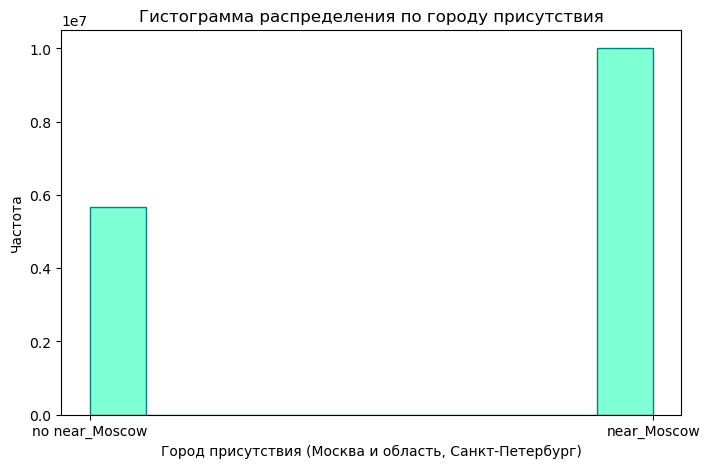

In [44]:
# Визуализируем данные
list_plot= ['aquamarine', 'teal', 'Город присутствия (Москва и область, Санкт-Петербург)', 'Частота', 'Гистограмма распределения по городу присутствия']
plot_data_all(df.geo_city, 'near_Moscow', 'no near_Moscow', city_tr, list_plot)

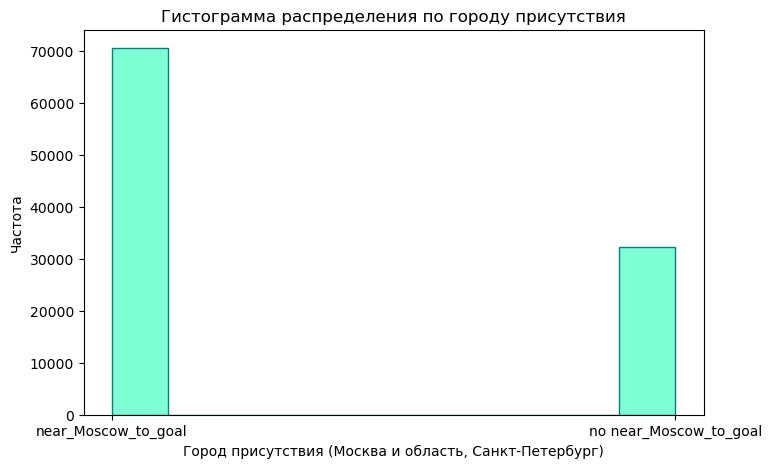

In [45]:
# Визуализируем данные по попаданию в цель
plot_data_to_goal(df.geo_city, df.conversion, 'near_Moscow', 'no near_Moscow', city_tr, list_plot)

In [46]:
df_city = pd.DataFrame()
df_city = create_cr_columns(df, 'main', 'other', 'geo_city', city_tr)

In [47]:
# Cчитаем CR
df_city['main_cr'] = df_city['main'] / (df_city.groupby('visit_date').sum().main + df_city.groupby('visit_date').sum().other) * 100
df_city['other_cr'] = df_city['other'] / (df_city.groupby('visit_date').sum().main + df_city.groupby('visit_date').sum().other) * 100

###### Гипотезы
Н0: CR из городов присутствия (Моска и область, Санкт_Петербург) равно CR из других городов.

Н1: CR из городов присутствия (Моска и область, Санкт_Петербург) отличается от CR из других городов.

In [48]:
hypothesis.append('Н0: CR из городов присутствия (Моска и область, Санкт_Петербург) равно CR из других городов. \
Н1: CR из городов присутствия (Моска и область, Санкт_Петербург) отличается от CR из других городов.')

In [49]:
# Проверяем на нормальность и равенство дисперсии
print(test_norm(df_city.main_cr, 0.05))
print(test_norm(df_city.other_cr, 0.05))
print(test_desp(df_city.main_cr, df_city.other_cr, 0.05))

Данные не распределены нормально.
Данные не распределены нормально.
Дисперсии не равны.


###### Т.к. данные не подчиняются нормальному распределению и независимы, то применяем критерий Манна-Уитни.

In [50]:
criterion.append('Т.к. данные не подчиняются нормальному распределению и независимы, то применяем критерий Манна-Уитни.')

In [51]:
check_test('Критерий Манна Уитни', df_city.main_cr, df_city.other_cr, 0.05, alternative ='less')

'Гипотезу Н0 отклонить нельзя.'

###### Вывод.¶¶
Согласно критерию Манна-Уитни принимаем гипотезу Н0. Значит, можно сказать, что трафик из городов присутствия не отличается от трафика из других городов.

In [52]:
conclusion.append('Согласно критерию Манна-Уитни принимаем гипотезу Н0. Значит, можно сказать, что трафик из городов присутствия не отличается от трафика из других городов.')

### Ответы на вопросы продуктовой команды:

In [53]:
# Функция считает долю категории и записывает в словарь
def find_best_category(df, column_name):
    #формируем список устройств
    type_categ = df[column_name].unique()
    
    #считаем размер выборки
    n = df.shape[0]

    categ_share = {}

    for item in type_categ:
        share_volume = df[df[column_name] == item].shape[0] / n * 100
        categ_share[item] = round(share_volume, 1)

    return  categ_share

In [54]:
# Функция считает CR категории и записывает в словарь
def find_cr_category(df, column_name):
    #формируем список устройств
    type_categ = df[column_name].unique()
    
    #считаем
    n = df.shape[0]

    categ_share = {}
    
    df1 = df[df['conversion'] == 1]

    for item in type_categ:
        share_volume = df1[df1[column_name] == item].shape[0] / n * 100
        categ_share[item] = round(share_volume, 1)

    return  categ_share

In [55]:
#Массив вопросов и ответов
questions = []
answers = []

In [56]:
#Более одного целевого действия считает за одно
df_dop = df.groupby(['visit_date', 'session_id']).max()

In [57]:
# Визуализация по заданному параметру
def quest_plot(categor, top_n, color):
    category_counts = df_dop[categor].value_counts()

    category_counts.head(top_n).plot(kind = 'bar', color = color)
    plt.title(f'Топ {top_n} категорий')
    plt.xlabel('Категория')
    plt.ylabel('Частота')
    plt.show()

In [58]:
# Визуализация по заданному параметру, которые попали в целевое действие
def quest_plot_to_goal(categor, top_n, color):
    df1 = df_dop[df_dop['conversion'] == 1]

    category_counts = df1[categor].value_counts()

    category_counts.head(top_n).plot(kind = 'bar', color = color)
    plt.title(f'Топ {top_n} категорий, которые попали в целевое действие')
    plt.xlabel('Категория')
    plt.ylabel('Частота')
    plt.show()

### Из каких устройств к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?

In [59]:
# Считаем общий трафик по каждому устройству
device_share = find_best_category(df_dop, 'device_category')

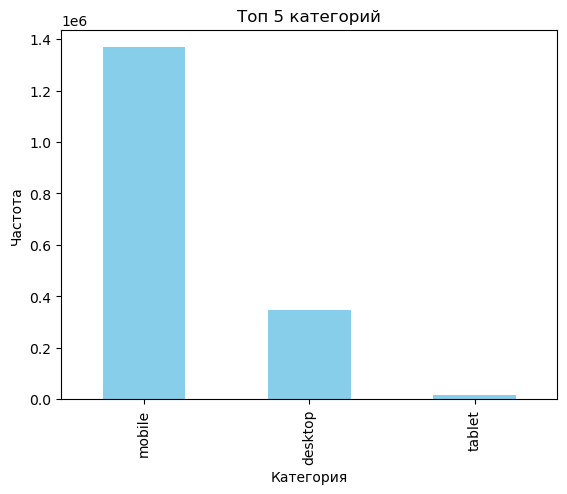

In [60]:
#Визуализация общих данных
quest_plot('device_category', 5, 'skyblue')

In [61]:
# Считаем CR по каждому устройству
device_share_cr = find_cr_category(df_dop, 'device_category')

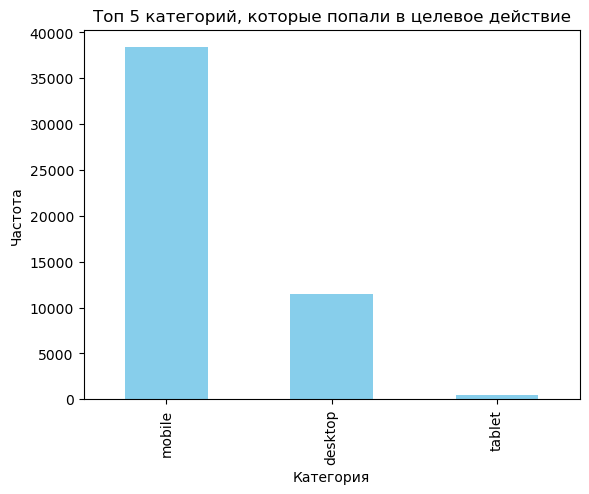

In [62]:
#Визуализация общих данных, которые попали в целевое действие
quest_plot_to_goal('device_category', 5, 'skyblue')

In [63]:
#Вычисляем максимальное значение
max_device = max(device_share, key = device_share.get)
max_device_cr = max(device_share_cr, key = device_share_cr.get)

#Записываем вопрос и ответ в списков
questions.append('Из каких устройств к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?')
answers.append(f'Наибольший объем трафика поступаем с {max_device}, его доля составляет {device_share[max_device]}%, \
 c точки зрения CR - с {max_device_cr}, его CR составляет {device_share_cr[max_device_cr]}%.')

In [64]:
answers[0]

'Наибольший объем трафика поступаем с mobile, его доля составляет 79.0%,  c точки зрения CR - с mobile, его CR составляет 2.2%.'

### Из каких локаций к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶

In [65]:
# Считаем общий трафик по каждой локации
country_share = find_best_category(df_dop, 'geo_country')

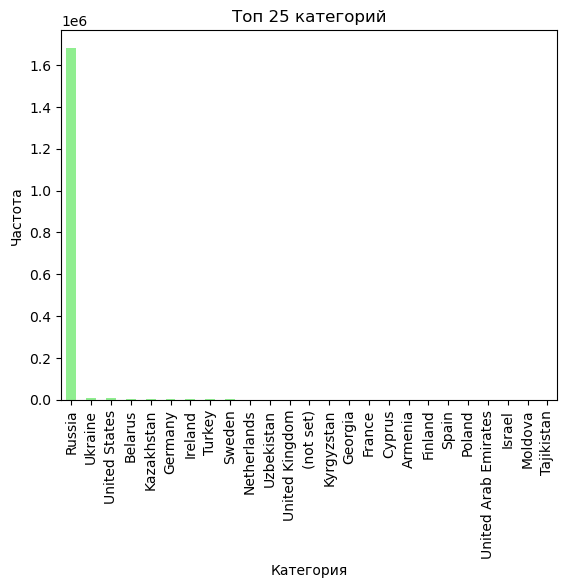

In [66]:
#Визуализация общих данных
quest_plot('geo_country', 25, 'lightgreen')

In [67]:
# Считаем CR по каждой локации
country_share_cr = find_cr_category(df_dop, 'geo_country')

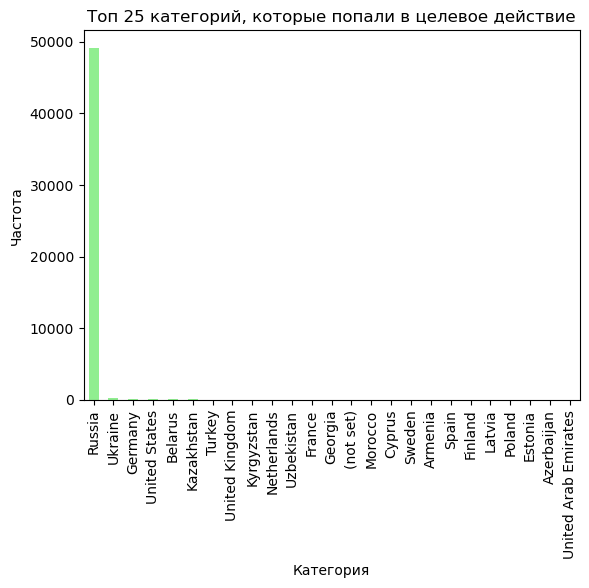

In [68]:
#Визуализация общих данных, которые попали в целевое действие
quest_plot_to_goal('geo_country', 25, 'lightgreen')

In [69]:
#Вычисляем максимальное значение
max_country = max(country_share, key = country_share.get)
max_country_cr = max(country_share_cr, key = country_share_cr.get)

#Записываем вопрос и ответ в списков
questions.append('Из каких локаций к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶?')
answers.append(f'Наибольший объем трафика поступаем из страны {max_country}, его доля составляет {country_share[max_country]}%,\
 с точки зрения CR - с {max_country_cr}, его CR составляет {country_share_cr[max_country_cr]}%.')

In [70]:
answers[1]

'Наибольший объем трафика поступаем из страны Russia, его доля составляет 97.1%, с точки зрения CR - с Russia, его CR составляет 2.8%.'

In [71]:
# Считаем общий трафик по каждому городу
city_share = find_best_category(df_dop, 'geo_city')

In [72]:
# Считаем CR по каждой локации
city_share_cr = find_cr_category(df_dop, 'geo_city')

In [73]:
#Вычисляем максимальное значение
max_city = max(city_share, key = city_share.get)
max_city_cr = max(city_share_cr, key = city_share_cr.get)

#Записываем вопрос и ответ в списков
questions.append('Из каких локаций к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶?')
answers.append(f'Наибольший объем трафика поступаем из города {max_city}, его доля составляет {city_share[max_city]}%,\
 c точки зрения CR - с {max_city_cr}, его CR составляет {city_share_cr[max_city_cr]}%.')

In [74]:
answers[2]

'Наибольший объем трафика поступаем из города Moscow, его доля составляет 43.3%, c точки зрения CR - с Moscow, его CR составляет 1.4%.'

### Из каких кампаний к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶¶

In [75]:
# Считаем общий трафик по каждой кампании
campaign_share = find_best_category(df_dop, 'utm_campaign')

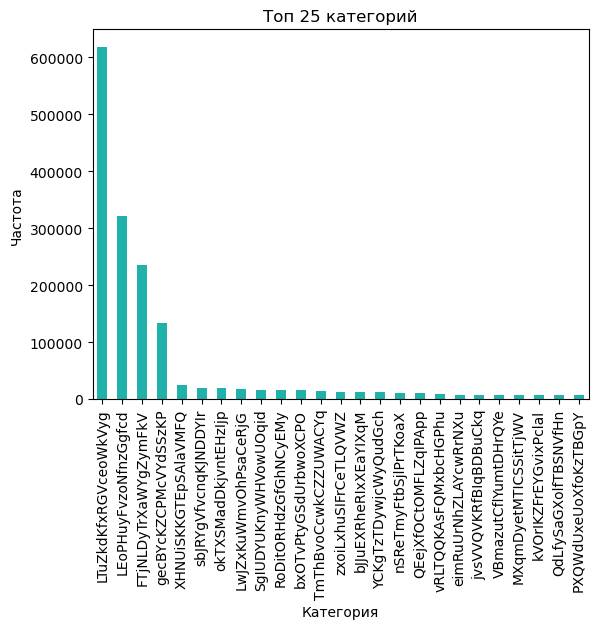

In [76]:
#Визуализация общих данных
quest_plot('utm_campaign', 25, 'lightseagreen')

In [77]:
# Считаем CR по каждой кампании
campaign_share_cr = find_cr_category(df_dop, 'utm_campaign')

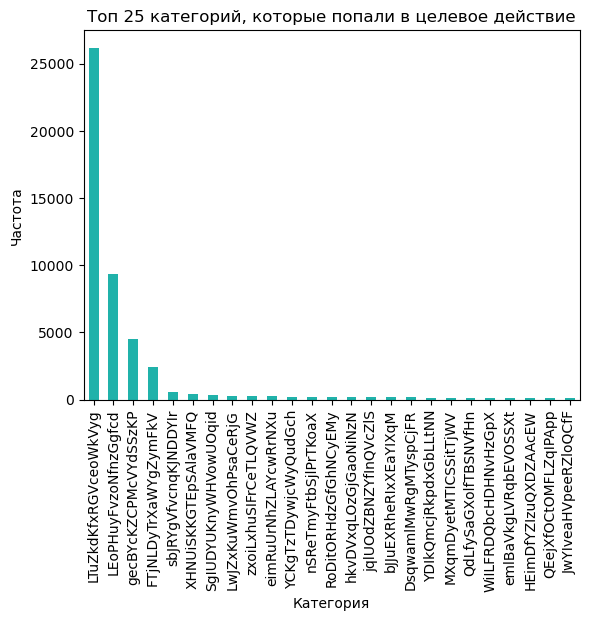

In [78]:
#Визуализация общих данных, которые попали в целевое действие
quest_plot_to_goal('utm_campaign', 25, 'lightseagreen')

In [79]:
#Вычисляем максимальное значение
max_campaign = max(campaign_share, key = campaign_share.get)
max_campaign_cr = max(campaign_share_cr, key = campaign_share_cr.get)

#Записываем вопрос и ответ в списков
questions.append('Из каких кампаний к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶?')
answers.append(f'Наибольший объем трафика поступаем из кампании {max_campaign}, его доля составляет {campaign_share[max_campaign]}%,\
 c точки зрения CR - с {max_campaign_cr}, его CR составляет {campaign_share_cr[max_campaign_cr]}%.')

In [80]:
answers[3]

'Наибольший объем трафика поступаем из кампании LTuZkdKfxRGVceoWkVyg, его доля составляет 35.7%, c точки зрения CR - с LTuZkdKfxRGVceoWkVyg, его CR составляет 1.5%.'

### Из каких источников к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶¶

In [81]:
# Считаем общий трафик по каждому источнику
source_share = find_best_category(df_dop, 'utm_source')

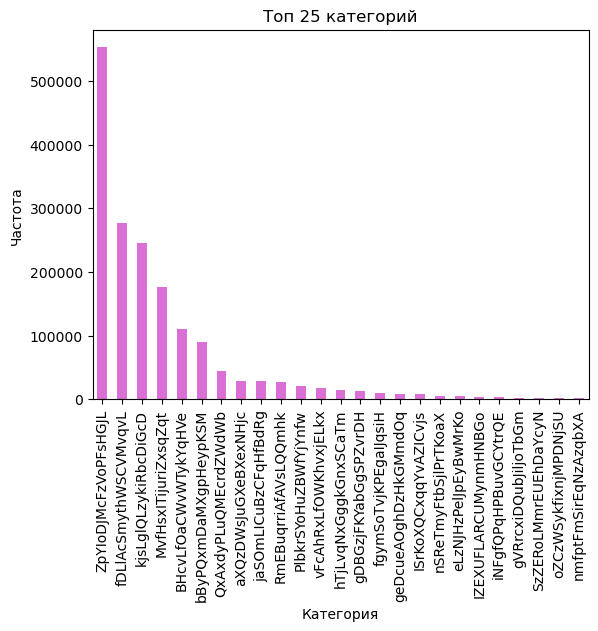

In [82]:
#Визуализация общих данных
quest_plot('utm_source', 25, 'orchid')

In [83]:
# Считаем CR по каждому источнику
source_share_cr = find_cr_category(df_dop, 'utm_source')

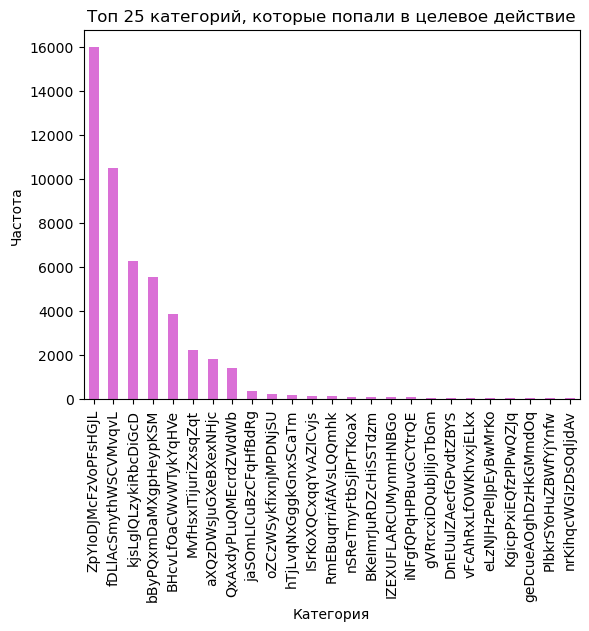

In [84]:
#Визуализация общих данных, которые попали в целевое действие
quest_plot_to_goal('utm_source', 25, 'orchid')

In [85]:
#Вычисляем максимальное значение
max_source = max(source_share, key = source_share.get)
max_source_cr = max(source_share_cr, key = source_share_cr.get)

#Записываем вопрос и ответ в списков
questions.append('Из каких источников к нам идет самый целевой трафик (и с точки зрения объема трафика, и с точки зрения CR)?¶?')
answers.append(f'Наибольший объем трафика поступаем из источника {max_source}, его доля составляет {source_share[max_source]}%,\
 с точки зрения CR - с {max_source_cr}, его СR составляет {source_share_cr[max_source_cr]}%.')

In [86]:
answers[4]

'Наибольший объем трафика поступаем из источника ZpYIoDJMcFzVoPFsHGJL, его доля составляет 31.9%, с точки зрения CR - с ZpYIoDJMcFzVoPFsHGJL, его СR составляет 0.9%.'

### Какие авто пользуются наибольшим спросом? У каких авто самый лучший показатель CR в целевые события?¶

In [87]:
# Считаем общий трафик по каждому авто
auto_share = find_best_category(df_dop, 'auto')

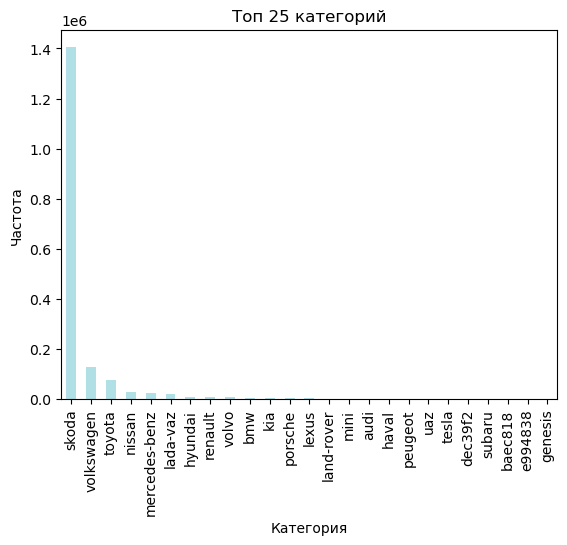

In [88]:
#Визуализация общих данных
quest_plot('auto', 25, 'powderblue')

In [89]:
# Считаем CR по каждому авто
auto_share_cr = find_cr_category(df_dop, 'auto')

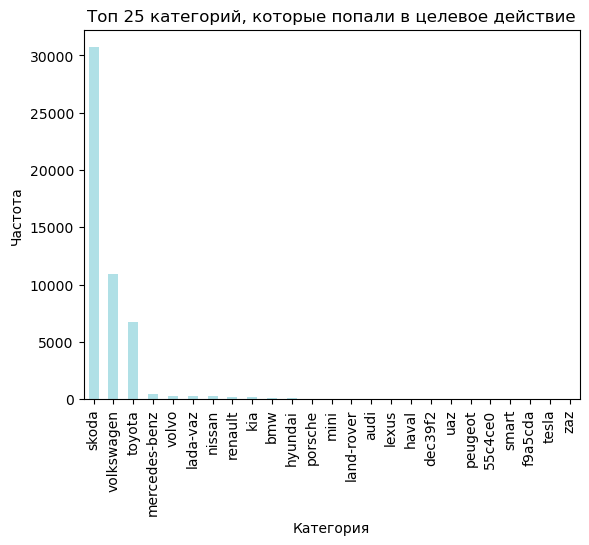

In [90]:
#Визуализация общих данных, которые попали в целевое действие
quest_plot_to_goal('auto', 25, 'powderblue')

In [91]:
# Сортируем по возрастанию
auto_count_sort = sorted(auto_share.items(), key = lambda item: item[1], reverse = True)
auto_count_cr_sort = sorted(auto_share_cr.items(), key = lambda item: item[1], reverse = True)

In [92]:
#Записываем вопрос и ответ в списков
questions.append('Какое авто пользуется наибольшим спросом?')
answers.append(f'В тройку самых популярных авто входят: {auto_count_sort[0][0]} (частота = {auto_count_sort[0][1]}); \
{auto_count_sort[1][0]} (частота = {auto_count_sort[1][1]}); {auto_count_sort[2][0]} (частота = {auto_count_sort[2][1]}).')

In [93]:
answers[5]

'В тройку самых популярных авто входят: skoda (частота = 81.1); volkswagen (частота = 7.3); toyota (частота = 4.4).'

In [94]:
#Записываем вопрос и ответ в списков
questions.append('У каких авто самый лучший показатель CR в целевые события?')
answers.append(f'В тройку авто c лучшими CR входят: {auto_count_cr_sort[0][0]} (CR = {auto_count_cr_sort[0][1]}); \
{auto_count_cr_sort[1][0]} (CR = {auto_count_cr_sort[1][1]}); {auto_count_cr_sort[2][0]} (CR = {auto_count_cr_sort[2][1]}).')

In [95]:
answers[6]

'В тройку авто c лучшими CR входят: skoda (CR = 1.8); volkswagen (CR = 0.6); toyota (CR = 0.4).'

### Стоит ли нам увеличивать свое присутствие в соцсетях и давать там больше рекламы?

In [96]:
#Формируем датафрейм по источнику = соцсети от всех
df_soc_all = df_dop[df_dop['utm_source'].isin(social_ad)]

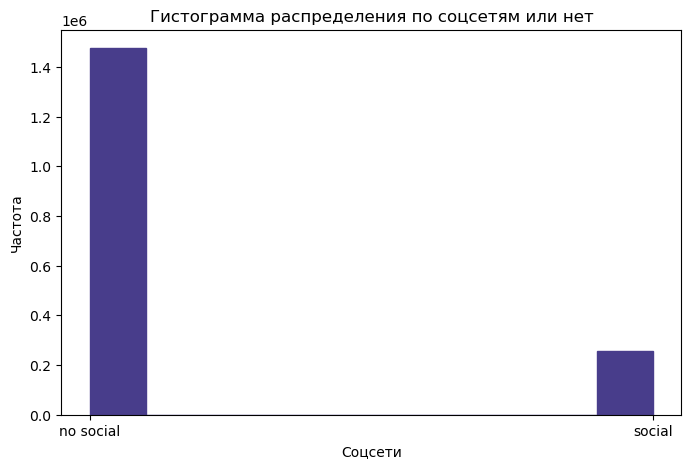

In [97]:
# Визуализируем данные
list_plot= ['darkslateblue', 'darkslateblue', 'Соцсети', 'Частота', 'Гистограмма распределения по соцсетям или нет']
plot_data_all(df_dop.utm_source, 'social', 'no social', social_ad, list_plot)

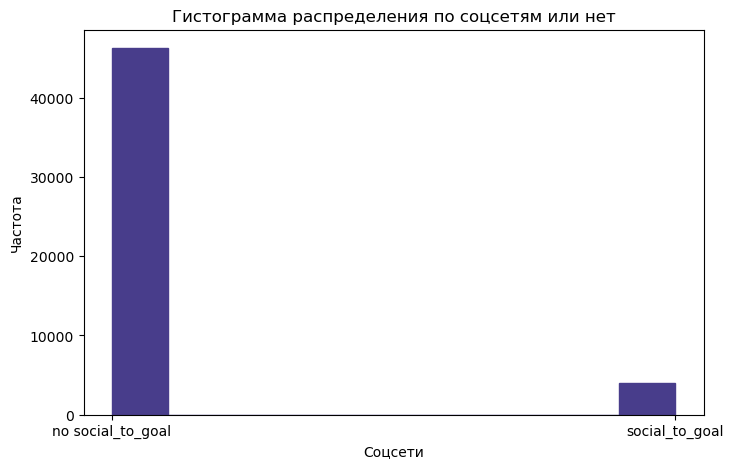

In [98]:
# Визуализируем данные по попаданию в цель
plot_data_to_goal(df_dop.utm_source, df_dop.conversion, 'social', 'no social', social_ad, list_plot)

In [99]:
#Доля соцсетей во всем трафике
share_soc_all = round(df_soc_all.shape[0]/df_dop.shape[0] * 100, 1)
# Доля соцсетей в трафике в целевое действие
df_soc_goal = df[df['conversion'] == 1]
share_soc_goal = round(df_soc_goal.shape[0]/df_dop.shape[0] * 100, 1)

In [100]:
# Функция оценки необходимости/отсутствия увеличения рекламы в соцсетях
def is_more_social_ad(share, min_value, medium_value):
    if share <= min_value:
        result = 'присутствие в соцсетях не надо увеличивать'
    elif share <= medium_value:
        result = 'необходимо доп исследование'
    else:
        result = 'присутствие в соцсетях стоит увеличить'
        
    return result

In [101]:
res_soc_all = is_more_social_ad(share_soc_all, 40, 60)
res_soc_goal = is_more_social_ad(share_soc_goal, 40, 60)
#Вычисляем итоговый результат
if res_soc_all == res_soc_goal or (res_soc_goal == 'присутствие в соцсетях стоит увеличить' and res_soc_all == 'необходимо доп исследование'):
    res = res_soc_goal
elif res_soc_all == 'присутствие в соцсетях стоит увеличить' or res_soc_goal == 'присутствие в соцсетях стоит увеличить':
    res = 'необходимо доп исследование'
else:
    res = 'присутствие в соцсетях не надо увеличивать'

#Записываем вопрос и ответ в списков
questions.append('Стоит ли нам увеличивать свое присутствие в соцсетях и давать там больше рекламы?')
answers.append(f'Доля трафика из социальных сетей составляет {share_soc_all}%, что говорит о том, \
что {res_soc_all}. Доля трафика из соцсетей в выборке, которая идет в целевое действие, составляет \
{share_soc_goal}%, что говорит о том, что {res_soc_goal}. Таким образом, {res}.')

In [102]:
answers[7]

'Доля трафика из социальных сетей составляет 14.8%, что говорит о том, что присутствие в соцсетях не надо увеличивать. Доля трафика из соцсетей в выборке, которая идет в целевое действие, составляет 5.9%, что говорит о том, что присутствие в соцсетях не надо увеличивать. Таким образом, присутствие в соцсетях не надо увеличивать.'

# Записываем ответы в файл

In [103]:
# Записываем ответы на вопросы в Excel на отдельный лист
df_quest_answ = pd.DataFrame()
df_quest_answ['question'] = questions
df_quest_answ['answers'] = answers

df_hypot = pd.DataFrame()
df_hypot['hypothesis'] = hypothesis
df_hypot['criterion'] = criterion
df_hypot['conclusion'] = conclusion

with pd.ExcelWriter("Total_answer.xlsx") as writer:
    df_quest_answ.to_excel(writer, sheet_name = "Прод_команда", index = 0)
    df_hypot.to_excel(writer, sheet_name = "Проверка_гипотез", index = 0)